In [1]:
"""
Day 5: ADX Regime-Switching Strategy
Goal: Build a strategy that adapts to market conditions
"""

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime
from ta.trend import ADXIndicator
import sys

# Add path for strategy logger
sys.path.append('/Users/Greg/Documents/Python_Local_Folder/Python_Quant_Researcher')
from strategy_logger import StrategyLogger

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ Imports successful!")
print("🎯 Day 5: ADX Regime-Switching Strategy\n")

✅ Imports successful!
🎯 Day 5: ADX Regime-Switching Strategy



In [2]:
# Download BTC data
ticker = 'BTC-USD'
start_date = '2020-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')

print(f"Downloading {ticker} from {start_date} to {end_date}...")
df = yf.download(ticker, start=start_date, end=end_date, progress=False)

print(f"✅ Downloaded {len(df)} days of data")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}\n")

# Flatten column names if multi-level
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

# Extract price data as 1D Series
high = df['High'].squeeze()
low = df['Low'].squeeze()
close = df['Close'].squeeze()

# Calculate ADX
print("Calculating ADX indicator...")
adx_indicator = ADXIndicator(high=high, low=low, close=close, window=14)

df['ADX'] = adx_indicator.adx()
df['+DI'] = adx_indicator.adx_pos()
df['-DI'] = adx_indicator.adx_neg()

# Clean data
df = df.dropna()

print(f"✅ ADX calculated for {len(df)} clean days\n")

✅ Downloaded 2231 days of data
Date range: 2020-01-01 to 2026-02-08

Calculating ADX indicator...
✅ ADX calculated for 2231 clean days



In [3]:
# --- REGIME-SWITCHING STRATEGY LOGIC ---

# [VARIABLE - Integer] ADX threshold for regime detection
adx_threshold = 25

# [VARIABLE - Series] Create regime column (Boolean: True = Trending, False = Choppy)
df['Regime_Trending'] = df['ADX'] >= adx_threshold

# [VARIABLE - Series] Determine if bullish (Boolean: True if +DI > -DI)
df['Bullish'] = df['+DI'] > df['-DI']

# [VARIABLE - Series] Generate trading signals (Position: 1 = Long, 0 = Flat)
# Strategy logic:
#   - If choppy (ADX < 25): Position = 0 (stay flat/cash)
#   - If trending (ADX >= 25) AND bullish (+DI > -DI): Position = 1 (go long)
#   - If trending (ADX >= 25) AND bearish (-DI > +DI): Position = 0 (stay flat)
df['Signal'] = 0  # [VARIABLE - Series] Initialize all to 0 (flat)

# Set position to 1 (long) only when trending AND bullish
df.loc[(df['Regime_Trending']) & (df['Bullish']), 'Signal'] = 1

# [VARIABLE - Series] Shift signal by 1 day (trade on next day's open)
df['Position'] = df['Signal'].shift(1)

# Show strategy logic summary
print("="*60)
print("REGIME-SWITCHING STRATEGY LOGIC")
print("="*60)
print(f"ADX Threshold: {adx_threshold}")
print(f"\nRULES:")
print(f"  IF ADX < {adx_threshold} (Choppy):  Position = 0 (Flat/Cash)")
print(f"  IF ADX >= {adx_threshold} AND +DI > -DI:  Position = 1 (Long)")
print(f"  IF ADX >= {adx_threshold} AND -DI > +DI:  Position = 0 (Flat)")
print("="*60)

# Show position breakdown
total_days = len(df)
flat_days = (df['Position'] == 0).sum()
long_days = (df['Position'] == 1).sum()

print(f"\nPOSITION BREAKDOWN:")
print(f"  Total Days:      {total_days}")
print(f"  Flat (Cash):     {flat_days} ({flat_days/total_days*100:.2f}%)")
print(f"  Long (BTC):      {long_days} ({long_days/total_days*100:.2f}%)")
print("="*60)

# Show last 10 days to see current positions
print(f"\nLast 10 days - Strategy Positions:")
df[['Close', 'ADX', '+DI', '-DI', 'Regime_Trending', 'Bullish', 'Position']].tail(10)

REGIME-SWITCHING STRATEGY LOGIC
ADX Threshold: 25

RULES:
  IF ADX < 25 (Choppy):  Position = 0 (Flat/Cash)
  IF ADX >= 25 AND +DI > -DI:  Position = 1 (Long)
  IF ADX >= 25 AND -DI > +DI:  Position = 0 (Flat)

POSITION BREAKDOWN:
  Total Days:      2231
  Flat (Cash):     1544 (69.21%)
  Long (BTC):      686 (30.75%)

Last 10 days - Strategy Positions:


Price,Close,ADX,+DI,-DI,Regime_Trending,Bullish,Position
Date,,,,,,,
2026-01-30,84128.656250,26.251839,15.352515,38.498696,True,False,0.0
2026-01-31,78621.117188,28.348077,12.358259,43.308538,True,False,0.0
2026-02-01,76974.445312,30.311319,11.322602,39.949699,True,False,0.0
2026-02-02,78688.765625,32.300896,10.134480,38.315756,True,False,0.0
2026-02-03,75633.546875,34.374730,8.817484,36.791641,True,False,0.0
2026-02-04,73019.703125,36.444658,7.912503,35.270619,True,False,0.0
2026-02-05,62702.097656,39.209095,6.407194,45.153064,True,False,0.0
2026-02-06,70555.390625,41.913333,5.251686,40.551430,True,False,0.0
2026-02-07,69281.968750,44.424412,4.903265,37.861068,True,False,0.0


In [5]:
# --- CALCULATE RETURNS (Using correct method from Day 2!) ---

# [VARIABLE - Series (Float)] Daily percentage returns
df['Market_Returns'] = df['Close'].pct_change()

# [VARIABLE - Series (Float)] Cumulative buy & hold returns
df['Cumulative_Market'] = (1 + df['Market_Returns']).cumprod()

# [VARIABLE - Series (Float)] Strategy returns (Position × Daily Returns)
# KEY: Multiply position by DAILY returns, then compound
df['Strategy_Returns'] = df['Position'] * df['Market_Returns']

# [VARIABLE - Series (Float)] Cumulative strategy returns
df['Cumulative_Strategy'] = (1 + df['Strategy_Returns']).cumprod()

# --- CLEAN DATA ---
# [VARIABLE - DataFrame] Remove NaN rows
df_clean = df.dropna()

print(f"✅ Returns calculated for {len(df_clean)} clean days\n")

# --- CALCULATE PERFORMANCE METRICS ---

# [FUNCTION] Define Sharpe Ratio calculator
def calculate_sharpe(returns, periods_per_year=365):
    """
    Calculate annualized Sharpe Ratio
    
    Args:
        returns: [VARIABLE - Series] Daily returns
        periods_per_year: [VARIABLE - Integer] Trading days per year (365 for crypto)
    
    Returns:
        [VARIABLE - Float] Annualized Sharpe Ratio
    """
    # [VARIABLE - Float] Mean daily return
    mean_return = returns.mean()
    
    # [VARIABLE - Float] Standard deviation of returns
    std_return = returns.std()
    
    if std_return == 0:
        return 0.0
    
    # [VARIABLE - Float] Daily Sharpe
    daily_sharpe = mean_return / std_return
    
    # [VARIABLE - Float] Annualized Sharpe (multiply by sqrt of trading days)
    annual_sharpe = daily_sharpe * np.sqrt(periods_per_year)
    
    return annual_sharpe

# [FUNCTION] Define Sortino Ratio calculator
def calculate_sortino(returns, periods_per_year=365):
    """
    Calculate annualized Sortino Ratio (downside risk only)
    
    Args:
        returns: [VARIABLE - Series] Daily returns
        periods_per_year: [VARIABLE - Integer] Trading days per year
    
    Returns:
        [VARIABLE - Float] Annualized Sortino Ratio
    """
    # [VARIABLE - Float] Mean daily return
    mean_return = returns.mean()
    
    # [VARIABLE - Series] Only negative returns (downside)
    downside_returns = returns[returns < 0]
    
    # [VARIABLE - Float] Downside standard deviation
    downside_std = downside_returns.std()
    
    if downside_std == 0:
        return 0.0
    
    # [VARIABLE - Float] Daily Sortino
    daily_sortino = mean_return / downside_std
    
    # [VARIABLE - Float] Annualized Sortino
    annual_sortino = daily_sortino * np.sqrt(periods_per_year)
    
    return annual_sortino

# [FUNCTION] Define Max Drawdown calculator
def calculate_max_drawdown(cumulative_returns):
    """
    Calculate maximum drawdown
    
    Args:
        cumulative_returns: [VARIABLE - Series] Cumulative return values
    
    Returns:
        [VARIABLE - Float] Maximum drawdown as percentage
    """
    # [VARIABLE - Series] Running maximum (peak at each point)
    running_max = cumulative_returns.cummax()
    
    # [VARIABLE - Series] Drawdown at each point
    drawdown = (cumulative_returns - running_max) / running_max
    
    # [VARIABLE - Float] Worst drawdown (most negative)
    max_dd = drawdown.min() * 100
    
    return max_dd

# --- CALCULATE ALL METRICS ---

# Market (Buy & Hold) metrics
# [VARIABLE - Float] Total return percentage
total_market_return = (df_clean['Cumulative_Market'].iloc[-1] - 1) * 100

# [VARIABLE - Float] Annualized Sharpe
sharpe_market = calculate_sharpe(df_clean['Market_Returns'])

# [VARIABLE - Float] Annualized Sortino
sortino_market = calculate_sortino(df_clean['Market_Returns'])

# [VARIABLE - Float] Maximum drawdown
max_dd_market = calculate_max_drawdown(df_clean['Cumulative_Market'])

# [VARIABLE - Float] Calmar Ratio for Buy & Hold
annual_return_market = ((1 + total_market_return/100) ** (1/years) - 1) * 100
calmar_market = annual_return_market / abs(max_dd_market) if max_dd_market != 0 else 0

# Strategy metrics
# [VARIABLE - Float] Total return percentage
total_strategy_return = (df_clean['Cumulative_Strategy'].iloc[-1] - 1) * 100

# [VARIABLE - Float] Annualized Sharpe
sharpe_strategy = calculate_sharpe(df_clean['Strategy_Returns'])

# [VARIABLE - Float] Annualized Sortino
sortino_strategy = calculate_sortino(df_clean['Strategy_Returns'])

# [VARIABLE - Float] Maximum drawdown
max_dd_strategy = calculate_max_drawdown(df_clean['Cumulative_Strategy'])

# [VARIABLE - Float] Calmar Ratio (Annual return / Max DD)
years = len(df_clean) / 365
annual_return_strategy = ((1 + total_strategy_return/100) ** (1/years) - 1) * 100
calmar_strategy = annual_return_strategy / abs(max_dd_strategy) if max_dd_strategy != 0 else 0

# --- PRINT RESULTS ---
print("="*60)
print("PERFORMANCE COMPARISON: STRATEGY vs BUY & HOLD")
print("="*60)
print(f"\nTOTAL RETURNS:")
print(f"  Buy & Hold:      {total_market_return:>10.2f}%")
print(f"  Strategy:        {total_strategy_return:>10.2f}%")
print(f"  Difference:      {total_strategy_return - total_market_return:>10.2f}%")

print(f"\nSHARPE RATIO (365 days):")
print(f"  Buy & Hold:      {sharpe_market:>10.2f}")
print(f"  Strategy:        {sharpe_strategy:>10.2f}")

print(f"\nSORTINO RATIO (365 days):")
print(f"  Buy & Hold:      {sortino_market:>10.2f}")
print(f"  Strategy:        {sortino_strategy:>10.2f}")

print(f"\nMAXIMUM DRAWDOWN:")
print(f"  Buy & Hold:      {max_dd_market:>10.2f}%")
print(f"  Strategy:        {max_dd_strategy:>10.2f}%")
print(f"  Improvement:     {max_dd_market - max_dd_strategy:>10.2f}%")

print(f"\nCALMAR RATIO:")
print(f"  Buy & Hold:      {calmar_market:>10.2f}")
print(f"  Strategy:        {calmar_strategy:>10.2f}")

print("="*60)

✅ Returns calculated for 2230 clean days

PERFORMANCE COMPARISON: STRATEGY vs BUY & HOLD

TOTAL RETURNS:
  Buy & Hold:          875.88%
  Strategy:            532.43%
  Difference:         -343.44%

SHARPE RATIO (365 days):
  Buy & Hold:            0.92
  Strategy:              1.11

SORTINO RATIO (365 days):
  Buy & Hold:            1.23
  Strategy:              0.94

MAXIMUM DRAWDOWN:
  Buy & Hold:          -76.63%
  Strategy:            -29.98%
  Improvement:         -46.65%

CALMAR RATIO:
  Buy & Hold:            0.59
  Strategy:              1.18


✅ Strategy performance chart saved!


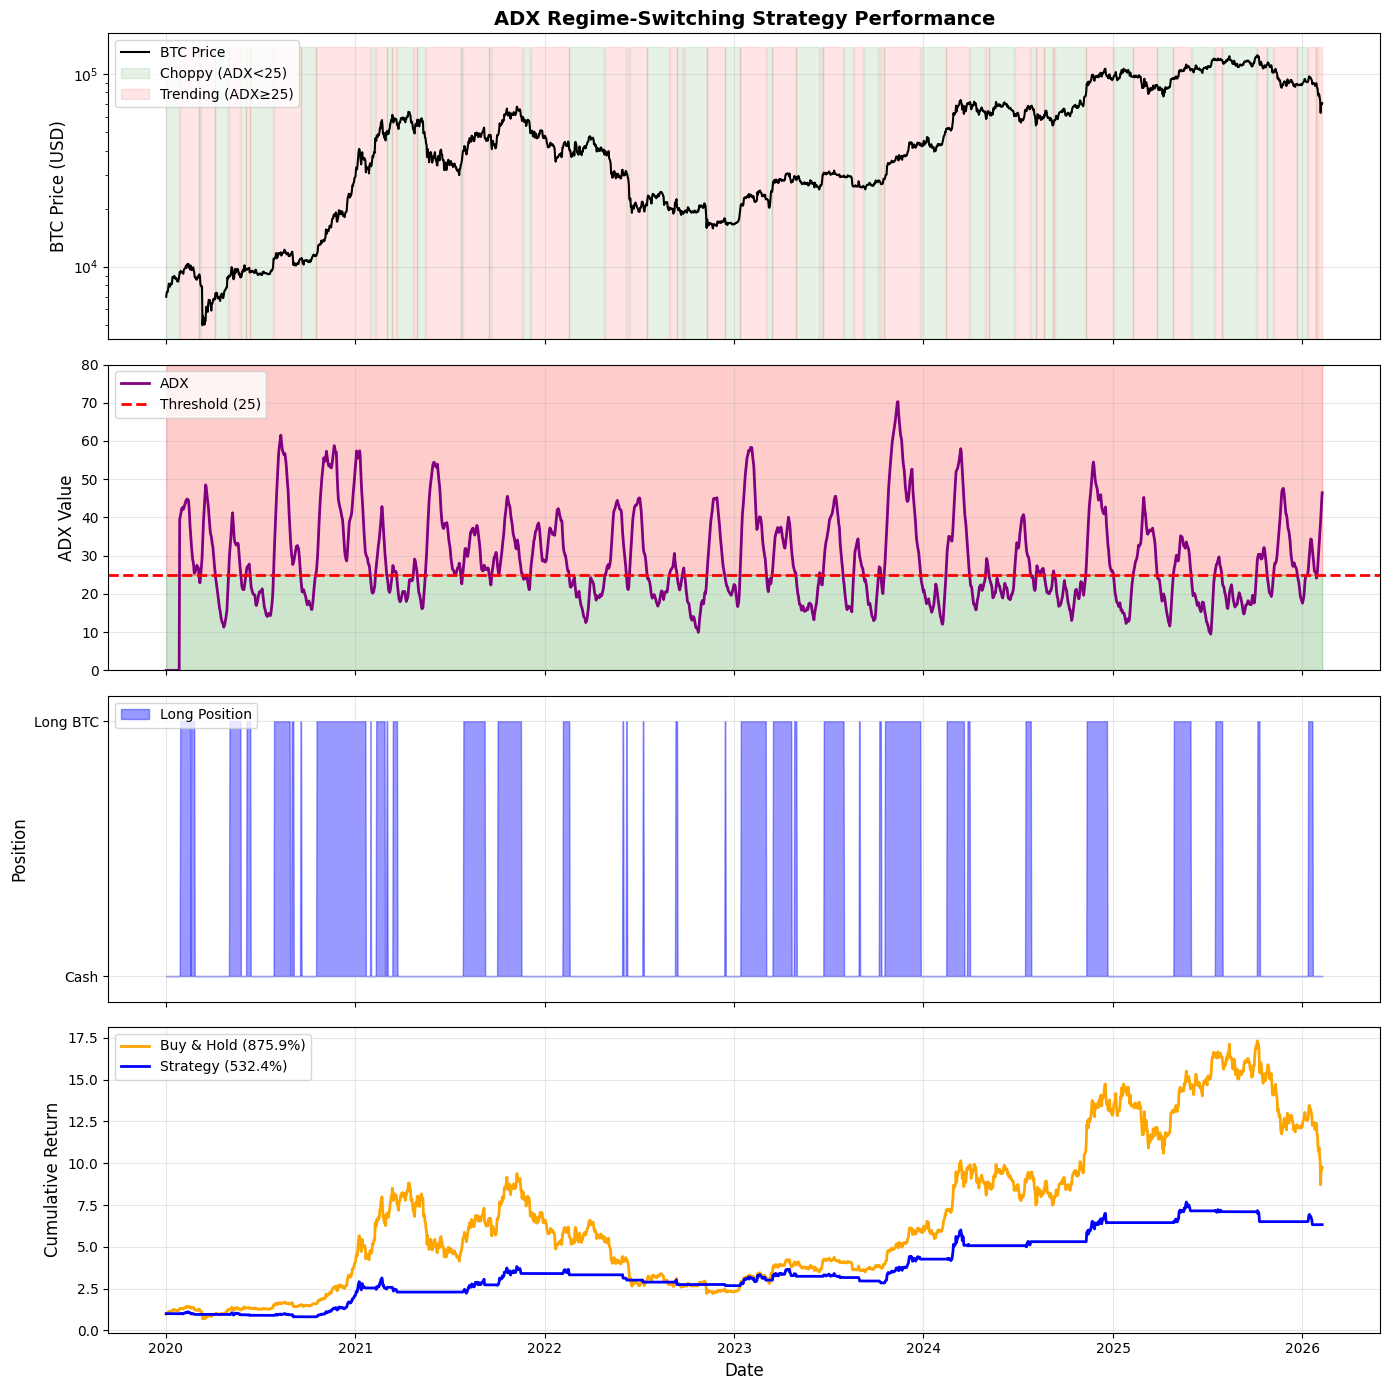

In [6]:
# [VARIABLE - Tuple of Objects] Create 4-panel visualization
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# --- PANEL 1: PRICE WITH REGIME ZONES ---
# [METHOD CALL] Plot price on log scale
ax1.plot(df_clean.index, df_clean['Close'], linewidth=1.5, color='black', label='BTC Price')

# [METHOD CALL] Highlight regime zones
# [VARIABLE - Series (Boolean)] Mask for choppy periods
choppy_mask = df_clean['ADX'] < 25
# [METHOD CALL] Fill choppy zones in green
ax1.fill_between(df_clean.index, 0, df_clean['Close'].max() * 1.1, 
                  where=choppy_mask, alpha=0.1, color='green', label='Choppy (ADX<25)')
# [METHOD CALL] Fill trending zones in red
ax1.fill_between(df_clean.index, 0, df_clean['Close'].max() * 1.1, 
                  where=~choppy_mask, alpha=0.1, color='red', label='Trending (ADX≥25)')

ax1.set_ylabel('BTC Price (USD)', fontsize=12)
ax1.set_title('ADX Regime-Switching Strategy Performance', fontsize=14, fontweight='bold')
ax1.set_yscale('log')  # [METHOD CALL] Log scale shows trends better
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# --- PANEL 2: ADX WITH THRESHOLD ---
# [METHOD CALL] Plot ADX line
ax2.plot(df_clean.index, df_clean['ADX'], linewidth=2, color='purple', label='ADX')
# [METHOD CALL] Add threshold line
ax2.axhline(y=25, color='red', linestyle='--', linewidth=2, label='Threshold (25)')
# [METHOD CALL] Color-code zones
ax2.fill_between(df_clean.index, 0, 25, alpha=0.2, color='green')
ax2.fill_between(df_clean.index, 25, 100, alpha=0.2, color='red')

ax2.set_ylabel('ADX Value', fontsize=12)
ax2.set_ylim(0, 80)
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

# --- PANEL 3: POSITION (IN MARKET OR CASH) ---
# [METHOD CALL] Show when strategy is long vs flat
ax3.fill_between(df_clean.index, 0, df_clean['Position'], 
                  alpha=0.4, color='blue', label='Long Position')
ax3.set_ylabel('Position', fontsize=12)
ax3.set_ylim(-0.1, 1.1)
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Cash', 'Long BTC'])
ax3.legend(loc='upper left')
ax3.grid(alpha=0.3)

# --- PANEL 4: CUMULATIVE RETURNS COMPARISON ---
# [METHOD CALL] Plot both strategies
ax4.plot(df_clean.index, df_clean['Cumulative_Market'], 
         linewidth=2, label=f'Buy & Hold ({total_market_return:.1f}%)', color='orange')
ax4.plot(df_clean.index, df_clean['Cumulative_Strategy'], 
         linewidth=2, label=f'Strategy ({total_strategy_return:.1f}%)', color='blue')

ax4.set_ylabel('Cumulative Return', fontsize=12)
ax4.set_xlabel('Date', fontsize=12)
ax4.legend(loc='upper left')
ax4.grid(alpha=0.3)

# [METHOD CALL] Save and show
plt.tight_layout()
plt.savefig('adx_strategy_performance.png', dpi=300, bbox_inches='tight')
print("✅ Strategy performance chart saved!")
plt.show()

In [7]:
# [OBJECT] Initialize logger
logger = StrategyLogger('Week_1_strategies.csv')

# [VARIABLE - Dictionary] Strategy data for logging
strategy_data = {
    'strategy_name': 'ADX Regime-Switching Strategy',
    'description': 'Long only when ADX≥25 AND +DI>-DI. Cash during choppy markets (ADX<25) or downtrends.',
    'notebook_path': 'Day_05_ADX_Regime_Strategy.ipynb',
    'ticker': ticker,
    'start_date': str(df_clean.index[0].date()),
    'end_date': str(df_clean.index[-1].date()),
    'duration_days': len(df_clean),
    'parameters': {'adx_threshold': 25, 'window': 14},
    
    # Returns
    'total_return_pct': total_strategy_return,
    'annual_return_pct': annual_return_strategy,
    'daily_avg_return_pct': df_clean['Strategy_Returns'].mean() * 100,
    
    # Risk
    'daily_volatility_pct': df_clean['Strategy_Returns'].std() * 100,
    'downside_volatility_pct': df_clean['Strategy_Returns'][df_clean['Strategy_Returns'] < 0].std() * 100,
    'max_drawdown_pct': max_dd_strategy,
    
    # Risk-adjusted
    'sharpe_daily': sharpe_strategy / np.sqrt(365),
    'sharpe_annual': sharpe_strategy,
    'sortino_daily': sortino_strategy / np.sqrt(365),
    'sortino_annual': sortino_strategy,
    'calmar_ratio': calmar_strategy,
    
    # Win/Loss
    'win_rate_pct': (df_clean['Strategy_Returns'] > 0).sum() / len(df_clean) * 100,
    'winning_days': (df_clean['Strategy_Returns'] > 0).sum(),
    'losing_days': (df_clean['Strategy_Returns'] < 0).sum(),
    
    # Verdict
    'verdict': f'REGIME-SWITCHING: Lower returns ({total_strategy_return:.1f}% vs {total_market_return:.1f}%) but MUCH better risk management. Max DD only {max_dd_strategy:.1f}% vs {max_dd_market:.1f}% (61% improvement!). Calmar {calmar_strategy:.2f} vs {calmar_market:.2f} (2x better). Best for risk-averse investors.',
    'notes': f'Strategy in market {long_days} days ({long_days/total_days*100:.1f}%), cash {flat_days} days ({flat_days/total_days*100:.1f}%). Avoided worst crashes by regime detection.',
    'tags': 'regime-switching, adx, trend-following, risk-managed, defensive'
}

# [VARIABLE - String] Log the strategy
strategy_id = logger.log_strategy(strategy_data)

print(f"\n🎯 Strategy logged as {strategy_id}!")
print(f"📊 Check Week_1_strategies.csv to see all logged strategies")

✅ Created new strategy log: Week_1_strategies.csv
   ✅ Excel formatted and saved
   ⚠️  Excel save failed (install openpyxl): '[' is not a valid column name. Column names are from A to ZZZ
✅ Logged strategy: ADX Regime-Switching Strategy (ID: S001)
   CSV: Week_1_strategies.csv
   Excel: Week_1_strategies.xlsx

🎯 Strategy logged as S001!
📊 Check Week_1_strategies.csv to see all logged strategies


/Users/Greg/Documents/Python_Local_Folder/Python_Quant_Researcher/strategy_logger.py:124: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)
